In [38]:
import numpy as np
import pandas as pd

path = "C:\\Users\\User0\\PycharmProjects\\zoomcamp-hw\\homeworks\\04-evaluation\\data\\course_lead_scoring_2026.csv"

df = pd.read_csv(path)

In [39]:
df.isna().sum().sort_values(ascending=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [40]:
target = 'converted'

categorical_features = df.select_dtypes(include=['object', 'str']).columns.tolist()

numerical_features = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if col != target
]

In [41]:
df[categorical_features] = df[categorical_features].fillna("NA")
df[numerical_features] = df[numerical_features].fillna(0)

In [42]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [43]:
from sklearn.metrics import roc_auc_score

features = ["lead_score","number_of_courses_viewed","interaction_count","annual_income"]\

y_train = df_train[target]
y_val = df_val[target]
y_test = df_test[target]

del df_train[target]
del df_val[target]
del df_test[target]


for feature in features:
    score = df_train[feature]
    auc = roc_auc_score(y_train, score)

    if auc < 0.5:
        auc = roc_auc_score(y_trian, -score)

    print(feature, auc)

lead_score 0.7882254810906102
number_of_courses_viewed 0.7229894623989618
interaction_count 0.7649203047563227
annual_income 0.6081977776250831


In [44]:
df_train.columns.tolist()

['lead_source',
 'industry',
 'employment_status',
 'location',
 'annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score']

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)
train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:,1]

print(round(roc_auc_score(y_val, y_pred),3))

0.732


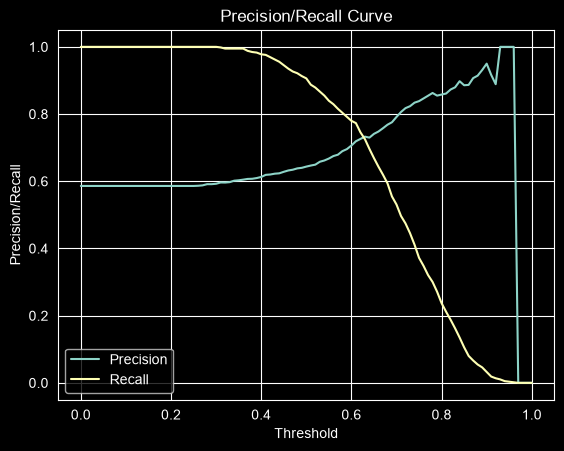

In [47]:
import matplotlib.pyplot as plt

thresholds=np.arange(0.0, 1.01, 0.01)

precisions = []
recalls = []

for threshold in thresholds:
    y_pred_binary = (y_pred >= threshold).astype(int)

    tp = ((y_pred_binary == 1) & (y_val == 1)).sum()
    fp = ((y_pred_binary == 1) & (y_val == 0)).sum()
    fn = ((y_pred_binary == 0) & (y_val == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0

    precisions.append(precision)
    recalls.append(recall)

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')
plt.title('Precision/Recall Curve')
plt.legend()
plt.show()


In [48]:
results = pd.DataFrame({"threshold": thresholds, "precision": precisions, "recall": recalls})

valid_results = results[
    ~((results.precision == 0) & (results.recall == 0))
].copy()

valid_results["difference"] = (
    valid_results.precision - valid_results.recall
).abs()

valid_results.sort_values("difference").head()

,threshold,precision,recall,difference
63,0.63,0.732759,0.725256,0.007503
62,0.62,0.725914,0.745734,0.019820
64,0.64,0.729875,0.696246,0.033629
61,0.61,0.719048,0.773038,0.053990
65,0.65,0.741021,0.668942,0.072079


In [50]:
results["f1"] = (2*results.precision*results.recall)/(results.precision+results.recall).fillna(0)
results.sort_values("f1",ascending=False).head()

,threshold,precision,recall,f1
41,0.41,0.619048,0.976109,0.757616
42,0.42,0.620087,0.969283,0.756325
43,0.43,0.622517,0.962457,0.756032
45,0.45,0.628118,0.945392,0.754768
44,0.44,0.623608,0.955631,0.754717


In [60]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
Cs = [0.000001,0.001,1]

for c in Cs:
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    scores=[]

    for train_idx, val_idx in kf.split(df_full_train):
        df_train_fold = df_full_train.iloc[train_idx]
        df_val_fold = df_full_train.iloc[val_idx]

        y_train_fold = df_train_fold[target]
        y_val_fold = df_val_fold[target]
        X_train_fold = df_train_fold.drop(target, axis=1)
        X_val_fold = df_val_fold.drop(target, axis=1)

        dv = DictVectorizer(sparse=False)

        X_train_dicts = X_train_fold.to_dict(orient='records')
        X_val_dicts = X_val_fold.to_dict(orient='records')

        X_train_encoded = dv.fit_transform(X_train_dicts)
        X_val_encoded = dv.transform(X_val_dicts)

        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
        model.fit(X_train_encoded, y_train_fold)

        y_pred_val = model.predict_proba(X_val_encoded)[:,1]
        auc = roc_auc_score(y_val_fold, y_pred_val)

        scores.append(auc)
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)

    print(f"C={c}: mean={mean_auc:.3f}, std={std_auc:.3f}")



C=1e-06: mean=0.617, std=0.019
C=0.001: mean=0.749, std=0.010
C=1: mean=0.732, std=0.007
